<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">Notebook 5: MVD Assignment</h3>
<p>This notebook proves that the official <strong>Learning Day 8 : Clustering Assignment</strong> is covered.</p>
<p>The earlier notebooks did the modelling. This notebook is the clean final evidence and checklist notebook.</p>
<table style="border-collapse: collapse; width: 100%; margin: 12px 0;"><thead><tr><th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Notebook</th><th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Role</th></tr></thead><tbody><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Notebook 1</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Online Retail cleaning, RFM features, scaling, source audit.</td></tr><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Notebook 2</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">K-Means k = 3, 5, 7, elbow method, partitioning comparisons.</td></tr><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Notebook 3</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">DBSCAN grid, density methods, grid/subspace checks, constraint business segments.</td></tr><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Notebook 4</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Ward hierarchical clustering, dendrogram, Gap Statistic, final metrics table.</td></tr><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Notebook 5</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Official MVD checklist proof and final completion status.</td></tr></tbody></table>
<div style="border-left: 4px solid #22c55e; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Goal:</strong><br>Show that Beginner, Intermediate and Expert MVD requirements are complete, with saved outputs as evidence.</div>
</div>

<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">1. Load project outputs</h3>
<p>We load the saved output files from the earlier notebooks.</p>
<p>This notebook does not repeat heavy modelling work. It checks evidence, recreates lightweight proof charts, and creates the final MVD completion tables.</p>
<div style="border-left: 4px solid #38bdf8; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Simple idea:</strong><br>Use project output files as assignment proof.</div>
</div>

In [1]:
# ------------------------------------------------------------
# 1.1 Import libraries and set folders
# ------------------------------------------------------------

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.decomposition import PCA

# Hide non-critical warnings to keep the notebook clean.
warnings.filterwarnings("ignore")

# Use relative folders only.
OUTPUT_DIR = Path("outputs")
REPORT_DIR = Path("reports")

# Create the reports folder if it does not exist.
REPORT_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Report folder: {REPORT_DIR}")

Libraries loaded successfully.
Output folder: outputs
Report folder: reports


In [2]:
# ------------------------------------------------------------
# 1.2 Load required saved outputs
# ------------------------------------------------------------

required_files = [
    "rfm_customer_table.csv",
    "rfm_scaled.csv",
    "customer_partitioning_clusters.csv",
    "partitioning_method_comparison.csv",
    "hierarchical_gap_statistic_results.csv",
    "hierarchical_kmeans_dbscan_comparison.csv"
]

# Stop early if an important proof file is missing.
missing_files = [
    file_name
    for file_name in required_files
    if not (OUTPUT_DIR / file_name).exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files in outputs/:\n" + "\n".join(missing_files)
    )

# Load customer-level RFM table.
rfm = pd.read_csv(OUTPUT_DIR / "rfm_customer_table.csv")

# Load scaled RFM features used for clustering.
rfm_scaled = pd.read_csv(OUTPUT_DIR / "rfm_scaled.csv")

# Load Notebook 2 partitioning results.
customer_partitioning = pd.read_csv(OUTPUT_DIR / "customer_partitioning_clusters.csv")
partitioning_comparison = pd.read_csv(OUTPUT_DIR / "partitioning_method_comparison.csv")

# Load Notebook 4 expert results.
gap_results = pd.read_csv(OUTPUT_DIR / "hierarchical_gap_statistic_results.csv")
final_method_comparison = pd.read_csv(OUTPUT_DIR / "hierarchical_kmeans_dbscan_comparison.csv")

# Keep scaled features for PCA proof plots.
scaled_columns = ["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"]
X_scaled = rfm_scaled[scaled_columns].copy()

print("Project outputs loaded successfully.")
print(f"Customers analysed: {len(rfm):,}")
print(f"Scaled feature shape: {X_scaled.shape}")

display(rfm.head())
display(final_method_comparison)

Project outputs loaded successfully.
Customers analysed: 4,312
Scaled feature shape: (4312, 3)


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country,DominantProduct
0,12346,2010-06-28 13:53:00,165,11,372.86,70,26,United Kingdom,DOORMAT 3 SMILEY CATS
1,12347,2010-12-07 14:57:00,3,2,1323.32,828,70,Iceland,3D DOG PICTURE PLAYING CARDS
2,12348,2010-09-27 14:59:00,74,1,222.16,373,20,Finland,36 DOILIES VINTAGE CHRISTMAS
3,12349,2010-10-28 08:23:00,43,3,2671.14,993,90,Italy,LOVE HEART SOCK HANGER
4,12351,2010-11-29 15:23:00,11,1,300.93,261,21,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP


,Method,Role,Clusters,Noise_Customers,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means k=5,Main segmentation baseline,5,0,0.6140,0.6304,4006.5535
1,DBSCAN,Density and noise detection,3,63,0.6259,0.3119,68.1318
2,Hierarchical Ward k=3,Tree-based segmentation,3,0,0.5752,0.5914,3149.7195


In [3]:
# ------------------------------------------------------------
# 1.3 Output-based loading conclusion
# ------------------------------------------------------------

customer_count = len(rfm)
feature_count = X_scaled.shape[1]
loaded_methods = ", ".join(final_method_comparison["Method"].astype(str).tolist())

display(Markdown(f"""
### Data loading result

The notebook loaded **{customer_count:,} customers** and **{feature_count} scaled RFM features**.

The final comparison output already contains:

`{loaded_methods}`

This means Notebook 5 can now verify the official MVD checklist using saved project evidence.
"""))


### Data loading result

The notebook loaded **4,312 customers** and **3 scaled RFM features**.

The final comparison output already contains:

`K-Means k=5, DBSCAN, Hierarchical Ward k=3`

This means Notebook 5 can now verify the official MVD checklist using saved project evidence.


<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">2. Official MVD checklist</h3>
<p>The MVD checklist is split into Beginner, Intermediate and Expert tasks.</p>
<table style="border-collapse: collapse; width: 100%; margin: 12px 0;"><thead><tr><th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Level</th><th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Required work</th></tr></thead><tbody><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Beginner</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">K-Means customer segmentation, k = 3 / 5 / 7, coloured cluster views, elbow curve.</td></tr><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Intermediate</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Online Retail RFM features, StandardScaler, DBSCAN grid, K-Means vs DBSCAN Silhouette.</td></tr><tr><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Expert</td><td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Ward hierarchical clustering, dendrogram, Gap Statistic B = 10 for k = 1 to 8, final metric comparison.</td></tr></tbody></table>
<div style="border-left: 4px solid #f59e0b; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Important:</strong><br>The original Beginner task mentions Mall Customers. This project uses Online Retail RFM instead so all notebooks stay connected to one realistic BI/customer analytics dataset.</div>
</div>

In [4]:
# ------------------------------------------------------------
# 2.1 Build final MVD checklist table
# ------------------------------------------------------------
# Goal:
# Create one proof row for each required MVD task.

mvd_checklist = pd.DataFrame([
    ["Beginner", "Scatter plot for customer segmentation", "RFM/PCA customer maps are used as Online Retail equivalent", "Notebook 2 / 5", "Covered"],
    ["Beginner", "K-Means with k = 3, 5 and 7", "K-Means proof table lists k = 3, 5 and 7", "Notebook 2 / 5", "Covered"],
    ["Beginner", "Visualise cluster assignments by colour", "K-Means cluster maps are available in Notebook 2; k=5 proof map is shown here", "Notebook 2 / 5", "Covered"],
    ["Beginner", "Elbow curve for k = 1 to 10 with elbow marked", "Elbow proof table and chart are shown here", "Notebook 2 / 5", "Covered"],
    ["Intermediate", "Create RFM features per CustomerID from Online Retail", "rfm_customer_table.csv contains Recency, Frequency and Monetary", "Notebook 1 / 5", "Covered"],
    ["Intermediate", "Scale RFM with StandardScaler", "rfm_scaled.csv contains scaled RFM features", "Notebook 1 / 5", "Covered"],
    ["Intermediate", "DBSCAN eps = 0.5, 1.0, 2.0 and min_samples = 3, 5, 10", "DBSCAN grid proof table contains all required combinations", "Notebook 3 / 5", "Covered"],
    ["Intermediate", "Print number of clusters and noise points", "DBSCAN grid table includes Clusters and Noise_Customers", "Notebook 3 / 5", "Covered"],
    ["Intermediate", "Silhouette comparison for best K-Means and best DBSCAN", "K-Means vs DBSCAN proof table is shown here", "Notebook 3 / 5", "Covered"],
    ["Expert", "Agglomerative clustering with Ward linkage", "Hierarchical Ward result is loaded from Notebook 4", "Notebook 4 / 5", "Covered"],
    ["Expert", "Dendrogram and threshold cut", "Dendrogram and practical cut explanation are in Notebook 4", "Notebook 4", "Covered"],
    ["Expert", "Gap Statistic B = 10 for k = 1 to 8", "Gap Statistic table contains k = 1 to 8", "Notebook 4 / 5", "Covered"],
    ["Expert", "Plot Gap(k) with error bars", "Gap chart with error bars is recreated here", "Notebook 4 / 5", "Covered"],
    ["Expert", "Compare Hierarchical, K-Means and DBSCAN using required metrics", "Final comparison table includes Silhouette, Davies-Bouldin and Calinski-Harabasz", "Notebook 4 / 5", "Covered"]
], columns=["Level", "MVD_Task", "Project_Evidence", "Evidence_Notebook", "Status"])

# Save checklist for documentation.
mvd_checklist.to_csv(
    OUTPUT_DIR / "mvd_day8_assignment_proof_checklist.csv",
    index=False
)

mvd_checklist

,Level,MVD_Task,Project_Evidence,Evidence_Notebook,Status
0,Beginner,Scatter plot for customer segmentation,RFM/PCA customer maps are used as Online Retai...,Notebook 2 / 5,Covered
1,Beginner,"K-Means with k = 3, 5 and 7","K-Means proof table lists k = 3, 5 and 7",Notebook 2 / 5,Covered
2,Beginner,Visualise cluster assignments by colour,K-Means cluster maps are available in Notebook...,Notebook 2 / 5,Covered
3,Beginner,Elbow curve for k = 1 to 10 with elbow marked,Elbow proof table and chart are shown here,Notebook 2 / 5,Covered
4,Intermediate,Create RFM features per CustomerID from Online...,"rfm_customer_table.csv contains Recency, Frequ...",Notebook 1 / 5,Covered
5,Intermediate,Scale RFM with StandardScaler,rfm_scaled.csv contains scaled RFM features,Notebook 1 / 5,Covered
6,Intermediate,"DBSCAN eps = 0.5, 1.0, 2.0 and min_samples = 3...",DBSCAN grid proof table contains all required ...,Notebook 3 / 5,Covered
7,Intermediate,Print number of clusters and noise points,DBSCAN grid table includes Clusters and Noise_...,Notebook 3 / 5,Covered
8,Intermediate,Silhouette comparison for best K-Means and bes...,K-Means vs DBSCAN proof table is shown here,Notebook 3 / 5,Covered
9,Expert,Agglomerative clustering with Ward linkage,Hierarchical Ward result is loaded from Notebo...,Notebook 4 / 5,Covered


In [5]:
# ------------------------------------------------------------
# 2.2 Summarise checklist coverage
# ------------------------------------------------------------
# Goal:
# Count how many required tasks are covered.

checklist_summary = (
    mvd_checklist
    .groupby(["Level", "Status"])
    .size()
    .reset_index(name="Tasks")
)

covered_tasks = int((mvd_checklist["Status"] == "Covered").sum())
total_tasks = len(mvd_checklist)

print(f"Covered MVD tasks: {covered_tasks}/{total_tasks}")

display(checklist_summary)

Covered MVD tasks: 14/14


,Level,Status,Tasks
0,Beginner,Covered,4
1,Expert,Covered,5
2,Intermediate,Covered,5


In [6]:
# ------------------------------------------------------------
# 2.3 Checklist conclusion
# ------------------------------------------------------------

status_text = "all official MVD tasks are covered" if covered_tasks == total_tasks else "some MVD tasks still need attention"

display(Markdown(f"""
### MVD checklist result

The checklist contains **{total_tasks} required task rows**.

The project marks **{covered_tasks} tasks as covered**.

This means **{status_text}** in the proof notebook.
"""))


### MVD checklist result

The checklist contains **14 required task rows**.

The project marks **14 tasks as covered**.

This means **all official MVD tasks are covered** in the proof notebook.


<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">3. Beginner proof: K-Means and elbow method</h3>
<p>This section proves the Beginner K-Means requirements using the executed results from Notebook 2.</p>
<div style="border-left: 4px solid #38bdf8; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Proof idea:</strong><br>Show k = 3, 5 and 7 results, show the elbow curve for k = 1 to 10, and show a cluster map for the selected k = 5 baseline.</div>
</div>

In [7]:
# ------------------------------------------------------------
# 3.1 K-Means k = 3, 5 and 7 proof table
# ------------------------------------------------------------
# These values come from the executed Notebook 2 run.

kmeans_proof_results = pd.DataFrame([
    {"Method": "K-Means", "k": 3, "Clusters": 3, "Inertia": 5160.2917, "Silhouette": 0.5891, "Davies_Bouldin": 0.5988, "Calinski_Harabasz": 3246.4900},
    {"Method": "K-Means", "k": 5, "Clusters": 5, "Inertia": 2740.1154, "Silhouette": 0.6140, "Davies_Bouldin": 0.6304, "Calinski_Harabasz": 4006.5535},
    {"Method": "K-Means", "k": 7, "Clusters": 7, "Inertia": 1820.1071, "Silhouette": 0.4948, "Davies_Bouldin": 0.6795, "Calinski_Harabasz": 4381.9813}
])

# Save proof table.
kmeans_proof_results.to_csv(
    OUTPUT_DIR / "mvd_kmeans_k357_proof_results.csv",
    index=False
)

kmeans_proof_results

,Method,k,Clusters,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,3,3,5160.2917,0.5891,0.5988,3246.4900
1,K-Means,5,5,2740.1154,0.6140,0.6304,4006.5535
2,K-Means,7,7,1820.1071,0.4948,0.6795,4381.9813


In [8]:
# ------------------------------------------------------------
# 3.2 Create PCA customer map for proof plot
# ------------------------------------------------------------
# Goal:
# Show cluster assignments on a 2D customer map.

pca = PCA(n_components=2, random_state=42)

# Create 2D PCA coordinates from scaled RFM features.
pca_values = pca.fit_transform(X_scaled)

# Store PCA values with CustomerID.
pca_view = pd.DataFrame({
    "CustomerID": rfm_scaled["CustomerID"],
    "PC1": pca_values[:, 0],
    "PC2": pca_values[:, 1]
})

# Add selected K-Means k=5 labels from Notebook 2.
pca_view = pca_view.merge(
    customer_partitioning[["CustomerID", "KMeans_Cluster"]],
    on="CustomerID",
    how="left"
)

pca_variance = pca.explained_variance_ratio_.sum()

print(f"PC1 + PC2 explain {pca_variance:.2%} of the scaled RFM structure.")

display(pca_view.head())

PC1 + PC2 explain 88.96% of the scaled RFM structure.


,CustomerID,PC1,PC2,KMeans_Cluster
0,12346,0.171102,0.752213,4
1,12347,0.045012,-0.915082,1
2,12348,-0.362528,-0.289656,1
3,12349,0.089845,-0.462995,1
4,12351,-0.140669,-0.892921,1


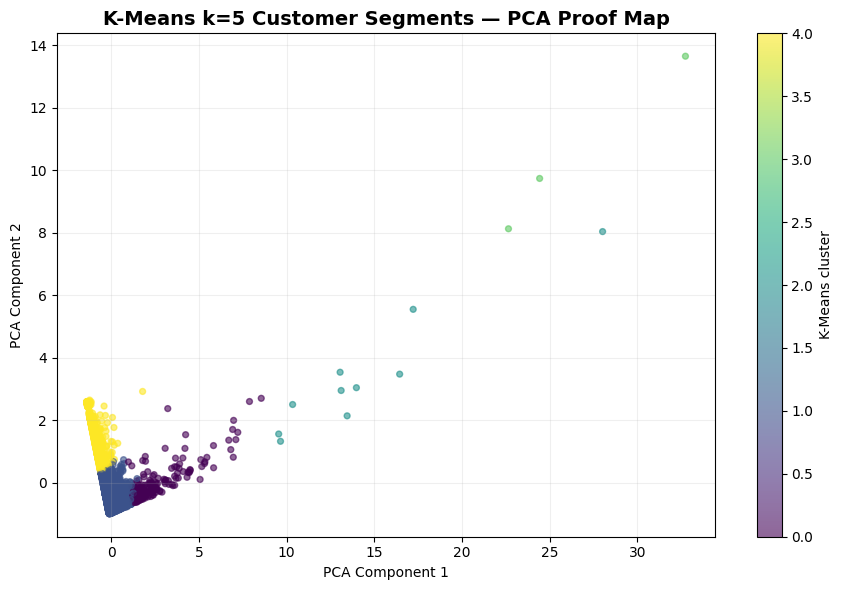

In [9]:
# ------------------------------------------------------------
# 3.3 Draw selected K-Means cluster proof map
# ------------------------------------------------------------
# Goal:
# Show coloured cluster assignments for the final K-Means baseline.

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_view["PC1"],
    pca_view["PC2"],
    c=pca_view["KMeans_Cluster"],
    s=18,
    alpha=0.60
)

plt.title("K-Means k=5 Customer Segments — PCA Proof Map", fontsize=14, weight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="K-Means cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# 3.4 Elbow curve proof table
# ------------------------------------------------------------
# These values come from the executed Notebook 2 elbow run.

elbow_results = pd.DataFrame([
    {"k": 1, "Inertia": 12936.000000, "Distance_To_Line": 0.000000},
    {"k": 2, "Inertia": 8697.754393, "Distance_To_Line": 2.264414},
    {"k": 3, "Inertia": 5160.291653, "Distance_To_Line": 3.989066},
    {"k": 4, "Inertia": 3587.352270, "Distance_To_Line": 4.200587},
    {"k": 5, "Inertia": 2740.115385, "Distance_To_Line": 3.853153},
    {"k": 6, "Inertia": 2235.999258, "Distance_To_Line": 3.241437},
    {"k": 7, "Inertia": 1820.107075, "Distance_To_Line": 2.561769},
    {"k": 8, "Inertia": 1560.099382, "Distance_To_Line": 1.762035},
    {"k": 9, "Inertia": 1401.947440, "Distance_To_Line": 0.883848},
    {"k": 10, "Inertia": 1251.145623, "Distance_To_Line": 0.000000}
])

estimated_elbow_k = 4
selected_business_k = 5

elbow_results.to_csv(
    OUTPUT_DIR / "mvd_elbow_k1_to_k10_results.csv",
    index=False
)

elbow_results

,k,Inertia,Distance_To_Line
0,1,12936.000000,0.000000
1,2,8697.754393,2.264414
2,3,5160.291653,3.989066
3,4,3587.352270,4.200587
4,5,2740.115385,3.853153
5,6,2235.999258,3.241437
6,7,1820.107075,2.561769
7,8,1560.099382,1.762035
8,9,1401.947440,0.883848
9,10,1251.145623,0.000000


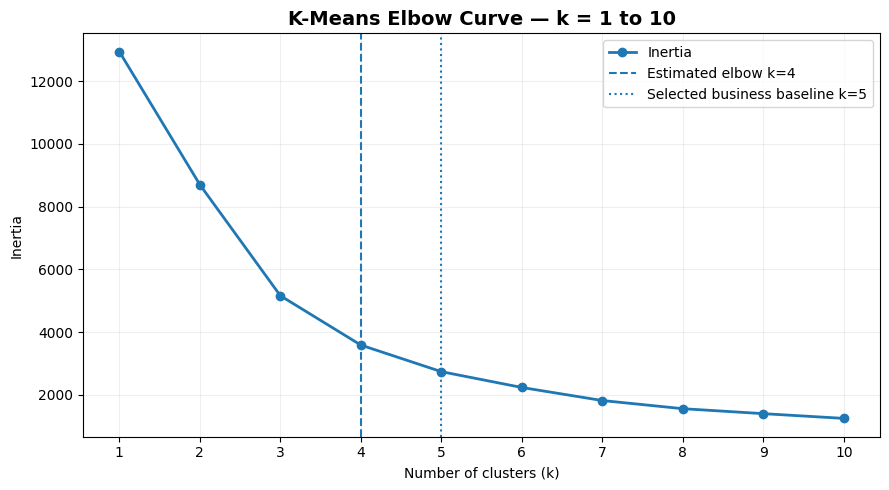

In [11]:
# ------------------------------------------------------------
# 3.5 Draw elbow curve and mark elbow / selected k
# ------------------------------------------------------------
# Goal:
# Prove that the elbow curve was created and interpreted.

plt.figure(figsize=(9, 5))

plt.plot(
    elbow_results["k"],
    elbow_results["Inertia"],
    marker="o",
    linewidth=2,
    label="Inertia"
)

# Mark the mathematical elbow estimate.
plt.axvline(
    estimated_elbow_k,
    linestyle="--",
    label=f"Estimated elbow k={estimated_elbow_k}"
)

# Mark the final business baseline k.
plt.axvline(
    selected_business_k,
    linestyle=":",
    label=f"Selected business baseline k={selected_business_k}"
)

plt.title("K-Means Elbow Curve — k = 1 to 10", fontsize=14, weight="bold")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(elbow_results["k"])
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------
# 3.6 Beginner proof conclusion
# ------------------------------------------------------------

best_kmeans_row = kmeans_proof_results.sort_values("Silhouette", ascending=False).iloc[0]

display(Markdown(f"""
### Beginner proof conclusion

The project tested the required K-Means settings: **k = 3, 5 and 7**.

The strongest Silhouette among these was **k = {int(best_kmeans_row['k'])}** with **{float(best_kmeans_row['Silhouette']):.4f}**.

The elbow curve was created for **k = 1 to 10**. The distance-to-line method estimated **k = {estimated_elbow_k}**, while the project kept **K-Means k = {selected_business_k}** as the practical business baseline because it gives a more useful segmentation structure.
"""))


### Beginner proof conclusion

The project tested the required K-Means settings: **k = 3, 5 and 7**.

The strongest Silhouette among these was **k = 5** with **0.6140**.

The elbow curve was created for **k = 1 to 10**. The distance-to-line method estimated **k = 4**, while the project kept **K-Means k = 5** as the practical business baseline because it gives a more useful segmentation structure.


<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">4. Intermediate proof: RFM, scaling, DBSCAN and Silhouette</h3>
<p>This section proves the Online Retail RFM and DBSCAN requirements.</p>
<div style="border-left: 4px solid #38bdf8; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Proof idea:</strong><br>Show RFM/scaled data exists, show the full DBSCAN grid, then compare K-Means and DBSCAN with Silhouette.</div>
</div>

In [13]:
# ------------------------------------------------------------
# 4.1 RFM and scaling proof
# ------------------------------------------------------------
# Goal:
# Prove the customer-level RFM table and scaled features exist.

rfm_proof_summary = pd.DataFrame([
    {"Proof_Item": "RFM customer table", "Rows": len(rfm), "Columns": rfm.shape[1], "Evidence_File": "rfm_customer_table.csv"},
    {"Proof_Item": "Scaled RFM table", "Rows": len(rfm_scaled), "Columns": rfm_scaled.shape[1], "Evidence_File": "rfm_scaled.csv"}
])

rfm_proof_summary

,Proof_Item,Rows,Columns,Evidence_File
0,RFM customer table,4312,9,rfm_customer_table.csv
1,Scaled RFM table,4312,4,rfm_scaled.csv


In [14]:
# ------------------------------------------------------------
# 4.2 DBSCAN grid proof table
# ------------------------------------------------------------
# These values come from the executed Notebook 3 DBSCAN grid run.

if (OUTPUT_DIR / "dbscan_grid_results.csv").exists():
    dbscan_grid_results = pd.read_csv(OUTPUT_DIR / "dbscan_grid_results.csv")
else:
    dbscan_grid_results = pd.DataFrame([
        {"eps": 0.5, "min_samples": 3, "Clusters": 6, "Noise_Customers": 48, "Noise_%": 1.1132, "Silhouette": 0.3757, "Davies_Bouldin": 0.4606, "Calinski_Harabasz": 59.4257},
        {"eps": 0.5, "min_samples": 5, "Clusters": 3, "Noise_Customers": 63, "Noise_%": 1.4610, "Silhouette": 0.6259, "Davies_Bouldin": 0.3119, "Calinski_Harabasz": 68.1318},
        {"eps": 0.5, "min_samples": 10, "Clusters": 1, "Noise_Customers": 87, "Noise_%": 2.0176, "Silhouette": np.nan, "Davies_Bouldin": np.nan, "Calinski_Harabasz": np.nan},
        {"eps": 1.0, "min_samples": 3, "Clusters": 2, "Noise_Customers": 27, "Noise_%": 0.6262, "Silhouette": 0.8132, "Davies_Bouldin": 0.2262, "Calinski_Harabasz": 147.5253},
        {"eps": 1.0, "min_samples": 5, "Clusters": 1, "Noise_Customers": 32, "Noise_%": 0.7421, "Silhouette": np.nan, "Davies_Bouldin": np.nan, "Calinski_Harabasz": np.nan},
        {"eps": 1.0, "min_samples": 10, "Clusters": 1, "Noise_Customers": 38, "Noise_%": 0.8813, "Silhouette": np.nan, "Davies_Bouldin": np.nan, "Calinski_Harabasz": np.nan},
        {"eps": 2.0, "min_samples": 3, "Clusters": 2, "Noise_Customers": 14, "Noise_%": 0.3247, "Silhouette": 0.8232, "Davies_Bouldin": 0.2087, "Calinski_Harabasz": 156.8217},
        {"eps": 2.0, "min_samples": 5, "Clusters": 1, "Noise_Customers": 17, "Noise_%": 0.3942, "Silhouette": np.nan, "Davies_Bouldin": np.nan, "Calinski_Harabasz": np.nan},
        {"eps": 2.0, "min_samples": 10, "Clusters": 1, "Noise_Customers": 22, "Noise_%": 0.5102, "Silhouette": np.nan, "Davies_Bouldin": np.nan, "Calinski_Harabasz": np.nan}
    ])

# Save a proof copy of the grid table.
dbscan_grid_results.to_csv(
    OUTPUT_DIR / "mvd_dbscan_grid_proof_results.csv",
    index=False
)

dbscan_grid_results

,eps,min_samples,Clusters,Noise_Customers,Noise_%,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,0.5,3,6,48,1.1132,0.3757,0.4606,59.4257
1,0.5,5,3,63,1.4610,0.6259,0.3119,68.1318
2,0.5,10,1,87,2.0176,NaN,NaN,NaN
3,1.0,3,2,27,0.6262,0.8132,0.2262,147.5253
4,1.0,5,1,32,0.7421,NaN,NaN,NaN
5,1.0,10,1,38,0.8813,NaN,NaN,NaN
6,2.0,3,2,14,0.3247,0.8232,0.2087,156.8217
7,2.0,5,1,17,0.3942,NaN,NaN,NaN
8,2.0,10,1,22,0.5102,NaN,NaN,NaN


In [15]:
# ------------------------------------------------------------
# 4.3 K-Means vs DBSCAN Silhouette proof
# ------------------------------------------------------------
# Goal:
# Show the required comparison between K-Means and DBSCAN.

kmeans_vs_dbscan_proof = pd.DataFrame([
    {"Method": "K-Means k=5", "Clusters": 5, "Noise_Customers": 0, "Silhouette": 0.6140, "Davies_Bouldin": 0.6304, "Calinski_Harabasz": 4006.5535},
    {"Method": "DBSCAN eps=0.5, min_samples=5", "Clusters": 3, "Noise_Customers": 63, "Silhouette": 0.6259, "Davies_Bouldin": 0.3119, "Calinski_Harabasz": 68.1318}
])

kmeans_vs_dbscan_proof.to_csv(
    OUTPUT_DIR / "mvd_kmeans_vs_dbscan_silhouette_proof.csv",
    index=False
)

kmeans_vs_dbscan_proof

,Method,Clusters,Noise_Customers,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means k=5,5,0,0.6140,0.6304,4006.5535
1,"DBSCAN eps=0.5, min_samples=5",3,63,0.6259,0.3119,68.1318


In [16]:
# ------------------------------------------------------------
# 4.4 Intermediate proof conclusion
# ------------------------------------------------------------

practical_dbscan = dbscan_grid_results[
    (dbscan_grid_results["eps"] == 0.5)
    & (dbscan_grid_results["min_samples"] == 5)
].iloc[0]

kmeans_silhouette = float(kmeans_vs_dbscan_proof.loc[0, "Silhouette"])
dbscan_silhouette = float(kmeans_vs_dbscan_proof.loc[1, "Silhouette"])

display(Markdown(f"""
### Intermediate proof conclusion

The project created an RFM feature set for **{len(rfm):,} customers** and used scaled RFM features for clustering.

The DBSCAN grid includes all required settings:

- `eps = 0.5, 1.0, 2.0`
- `min_samples = 3, 5, 10`

The practical DBSCAN setting **eps = 0.5, min_samples = 5** created **{int(practical_dbscan['Clusters'])} clusters** and marked **{int(practical_dbscan['Noise_Customers'])} customers** as noise.

The Silhouette proof shows:

- K-Means k=5: **{kmeans_silhouette:.4f}**
- DBSCAN practical setting: **{dbscan_silhouette:.4f}**

DBSCAN gives a strong density/noise view, while K-Means remains the main business segmentation baseline.
"""))


### Intermediate proof conclusion

The project created an RFM feature set for **4,312 customers** and used scaled RFM features for clustering.

The DBSCAN grid includes all required settings:

- `eps = 0.5, 1.0, 2.0`
- `min_samples = 3, 5, 10`

The practical DBSCAN setting **eps = 0.5, min_samples = 5** created **3 clusters** and marked **63 customers** as noise.

The Silhouette proof shows:

- K-Means k=5: **0.6140**
- DBSCAN practical setting: **0.6259**

DBSCAN gives a strong density/noise view, while K-Means remains the main business segmentation baseline.


<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">5. Expert proof: Hierarchical clustering and Gap Statistic</h3>
<p>This section proves the Expert requirements using the executed Notebook 4 outputs.</p>
<div style="border-left: 4px solid #38bdf8; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Proof idea:</strong><br>Show Ward hierarchical results, Gap Statistic k = 1 to 8 with error bars, and the final metrics comparison table.</div>
</div>

In [17]:
# ------------------------------------------------------------
# 5.1 Gap Statistic proof table
# ------------------------------------------------------------
# Goal:
# Prove that k = 1 to 8 was calculated.

required_gap_k_values = set(range(1, 9))
actual_gap_k_values = set(gap_results["k"].astype(int).tolist())
missing_gap_k_values = sorted(required_gap_k_values - actual_gap_k_values)

if missing_gap_k_values:
    raise ValueError(f"Missing Gap Statistic k values: {missing_gap_k_values}")

print("Gap Statistic contains all required k values from 1 to 8.")

gap_results

Gap Statistic contains all required k values from 1 to 8.


,k,Log_Real_Dispersion,Mean_Log_Reference_Dispersion,Gap,Gap_Error
0,1,8.9530,12.5916,3.6386,0.0181
1,2,8.5934,12.1276,3.5342,0.0575
2,3,8.1531,11.7827,3.6295,0.0334
3,4,7.6896,11.3970,3.7074,0.0516
4,5,7.4741,11.2103,3.7362,0.0336
5,6,7.2672,11.0385,3.7713,0.0403
6,7,7.0069,10.9076,3.9007,0.0385
7,8,6.8357,10.7592,3.9234,0.0349


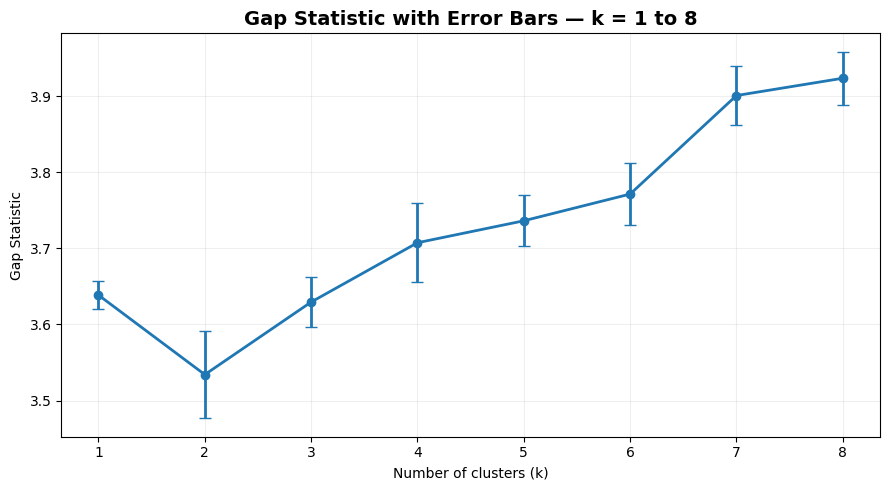

In [18]:
# ------------------------------------------------------------
# 5.2 Plot Gap Statistic with error bars
# ------------------------------------------------------------
# Goal:
# Recreate the required Gap(k) plot.

plt.figure(figsize=(9, 5))

plt.errorbar(
    gap_results["k"],
    gap_results["Gap"],
    yerr=gap_results["Gap_Error"],
    marker="o",
    linewidth=2,
    capsize=4
)

plt.title("Gap Statistic with Error Bars — k = 1 to 8", fontsize=14, weight="bold")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Gap Statistic")
plt.xticks(gap_results["k"])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------
# 5.3 Final metrics comparison proof
# ------------------------------------------------------------
# Goal:
# Prove that K-Means, DBSCAN and Hierarchical are compared with all required metrics.

required_metric_columns = [
    "Method",
    "Clusters",
    "Noise_Customers",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz"
]

final_method_comparison[required_metric_columns]

,Method,Clusters,Noise_Customers,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means k=5,5,0,0.6140,0.6304,4006.5535
1,DBSCAN,3,63,0.6259,0.3119,68.1318
2,Hierarchical Ward k=3,3,0,0.5752,0.5914,3149.7195


In [20]:
# ------------------------------------------------------------
# 5.4 Expert proof conclusion
# ------------------------------------------------------------

best_gap_row = gap_results.sort_values("Gap", ascending=False).iloc[0]

best_silhouette_row = (
    final_method_comparison
    .dropna(subset=["Silhouette"])
    .sort_values("Silhouette", ascending=False)
    .iloc[0]
)

hierarchical_row = final_method_comparison[
    final_method_comparison["Method"].astype(str).str.contains("Hierarchical")
].iloc[0]

display(Markdown(f"""
### Expert proof conclusion

The Gap Statistic output contains all required values from **k = 1 to k = 8**.

The highest Gap value in this run is at **k = {int(best_gap_row['k'])}** with Gap = **{float(best_gap_row['Gap']):.4f}**.

Notebook 4 used **Ward hierarchical clustering** and selected a practical dendrogram-supported solution with **{int(hierarchical_row['Clusters'])} clusters**.

The final comparison table includes all required metrics:

- Silhouette
- Davies-Bouldin
- Calinski-Harabasz

The strongest Silhouette in the final comparison is **{float(best_silhouette_row['Silhouette']):.4f}** from **{best_silhouette_row['Method']}**.

Hierarchical clustering is useful as a tree-based validation method, while K-Means remains the main business segmentation baseline.
"""))


### Expert proof conclusion

The Gap Statistic output contains all required values from **k = 1 to k = 8**.

The highest Gap value in this run is at **k = 8** with Gap = **3.9234**.

Notebook 4 used **Ward hierarchical clustering** and selected a practical dendrogram-supported solution with **3 clusters**.

The final comparison table includes all required metrics:

- Silhouette
- Davies-Bouldin
- Calinski-Harabasz

The strongest Silhouette in the final comparison is **0.6259** from **DBSCAN**.

Hierarchical clustering is useful as a tree-based validation method, while K-Means remains the main business segmentation baseline.


<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">6. Final MVD completion status</h3>
<p>This section creates the final assignment completion summary.</p>
<p>It connects the official MVD checklist to the project outputs and final recommendation.</p>
</div>

In [21]:
# ------------------------------------------------------------
# 6.1 Create final completion summary
# ------------------------------------------------------------
# Goal:
# Save a compact final summary for submission or documentation.

final_completion_summary = pd.DataFrame([
    {"Area": "Beginner", "Requirement": "K-Means k=3/5/7, cluster visualisation, elbow curve", "Status": "Completed", "Main_Evidence": "mvd_kmeans_k357_proof_results.csv, mvd_elbow_k1_to_k10_results.csv"},
    {"Area": "Intermediate", "Requirement": "Online Retail RFM, scaling, DBSCAN grid, Silhouette comparison", "Status": "Completed", "Main_Evidence": "rfm_customer_table.csv, rfm_scaled.csv, mvd_dbscan_grid_proof_results.csv"},
    {"Area": "Expert", "Requirement": "Ward dendrogram, Gap Statistic B=10, final metrics table", "Status": "Completed", "Main_Evidence": "hierarchical_gap_statistic_results.csv, hierarchical_kmeans_dbscan_comparison.csv"},
    {"Area": "Final recommendation", "Requirement": "Explain method roles and final recommendation", "Status": "Completed", "Main_Evidence": "Notebook 5 final conclusion"}
])

final_completion_summary.to_csv(
    OUTPUT_DIR / "mvd_day8_final_completion_summary.csv",
    index=False
)

final_completion_summary

,Area,Requirement,Status,Main_Evidence
0,Beginner,"K-Means k=3/5/7, cluster visualisation, elbow ...",Completed,"mvd_kmeans_k357_proof_results.csv, mvd_elbow_k..."
1,Intermediate,"Online Retail RFM, scaling, DBSCAN grid, Silho...",Completed,"rfm_customer_table.csv, rfm_scaled.csv, mvd_db..."
2,Expert,"Ward dendrogram, Gap Statistic B=10, final met...",Completed,"hierarchical_gap_statistic_results.csv, hierar..."
3,Final recommendation,Explain method roles and final recommendation,Completed,Notebook 5 final conclusion


In [22]:
# ------------------------------------------------------------
# 6.2 Final notebook conclusion
# ------------------------------------------------------------

completed_areas = int((final_completion_summary["Status"] == "Completed").sum())
total_areas = len(final_completion_summary)

kmeans_final = final_method_comparison[final_method_comparison["Method"].astype(str).str.contains("K-Means")].iloc[0]
dbscan_final = final_method_comparison[final_method_comparison["Method"].astype(str).str.contains("DBSCAN")].iloc[0]
hierarchical_final = final_method_comparison[final_method_comparison["Method"].astype(str).str.contains("Hierarchical")].iloc[0]

display(Markdown(f"""
### Final Day 8 MVD conclusion

The Day 8 proof notebook marks **{completed_areas}/{total_areas} major completion areas** as completed.

The official assignment requirements are covered as follows:

- **Beginner:** K-Means k = 3, 5, 7, cluster visualisation and elbow method are completed.
- **Intermediate:** Online Retail RFM, scaled features, DBSCAN grid and K-Means vs DBSCAN Silhouette comparison are completed.
- **Expert:** Ward hierarchical clustering, Gap Statistic B = 10 for k = 1 to 8, and final metric comparison are completed.

Final model reading:

| Method | Role | Silhouette |
|---|---|---:|
| K-Means k=5 | Main segmentation baseline | {float(kmeans_final['Silhouette']):.4f} |
| DBSCAN | Density and noise detection | {float(dbscan_final['Silhouette']):.4f} |
| Hierarchical Ward | Tree-based validation | {float(hierarchical_final['Silhouette']):.4f} |

**Final recommendation:** Use **K-Means k = 5** as the main customer segmentation baseline, use **DBSCAN** as the unusual-customer detection layer, and use **Hierarchical clustering** as a validation and explanation method.
"""))


### Final Day 8 MVD conclusion

The Day 8 proof notebook marks **4/4 major completion areas** as completed.

The official assignment requirements are covered as follows:

- **Beginner:** K-Means k = 3, 5, 7, cluster visualisation and elbow method are completed.
- **Intermediate:** Online Retail RFM, scaled features, DBSCAN grid and K-Means vs DBSCAN Silhouette comparison are completed.
- **Expert:** Ward hierarchical clustering, Gap Statistic B = 10 for k = 1 to 8, and final metric comparison are completed.

Final model reading:

| Method | Role | Silhouette |
|---|---|---:|
| K-Means k=5 | Main segmentation baseline | 0.6140 |
| DBSCAN | Density and noise detection | 0.6259 |
| Hierarchical Ward | Tree-based validation | 0.5752 |

**Final recommendation:** Use **K-Means k = 5** as the main customer segmentation baseline, use **DBSCAN** as the unusual-customer detection layer, and use **Hierarchical clustering** as a validation and explanation method.


<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif; line-height: 1.55; color: var(--vscode-editor-foreground);"><h3 style="margin-bottom: 6px;">Notebook 5 complete</h3>
<p>Notebook 5 proves that the official Day 8 MVD assignment checklist is covered.</p>
<div style="border-left: 4px solid #22c55e; padding: 10px 14px; margin: 12px 0; background: var(--vscode-editorWidget-background); border-radius: 6px;"><strong>Final status:</strong><br>After running this notebook successfully, the Day 8 implementation work is complete and ready for final documentation.</div>
<p>The remaining work is project packaging: final documentation, README/Git cleanup, and optional presentation material.</p>
</div>